# Plume Manager Showcase Dataset Builder

This notebook builds a small folder-based plume dataset for practice, demos, and screenshots without touching the production `src/` code.

Recommended workflow:

1. Point the notebook at one already-packed plume `.h5` archive.
2. Export only a few targets, plume folders, and frames back into the folder layout expected by the plume manager.
3. Write a lightweight metadata JSON file from a template.
4. Optionally repack the tiny showcase folder into a second demo `.h5` archive to verify the round trip.


In [1]:
from __future__ import annotations

from copy import deepcopy
from pathlib import Path
import json
import shutil
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pld_workflow.plume_management import build_plume_archive_stem, pack_plume_directory, scan_plume_directory


def normalize_uint8_frame(frame: np.ndarray) -> np.ndarray:
    array = np.asarray(frame)
    if array.dtype.kind == "f":
        max_value = float(array.max()) if array.size else 0.0
        if max_value <= 1.0:
            array = array * 255.0
    return np.clip(array, 0, 255).astype(np.uint8)


def export_showcase_from_archive(
    archive_path: Path,
    output_root: Path,
    *,
    max_targets: int = 2,
    max_plumes_per_target: int = 2,
    max_frames_per_plume: int = 6,
) -> list[dict[str, object]]:
    archive_path = Path(archive_path).expanduser().resolve()
    output_root = Path(output_root).expanduser().resolve()
    output_root.mkdir(parents=True, exist_ok=True)

    summary: list[dict[str, object]] = []
    with h5py.File(archive_path, "r") as handle:
        if "PLD_Plumes" not in handle:
            raise KeyError(f"{archive_path} does not contain a 'PLD_Plumes' group.")

        plume_group = handle["PLD_Plumes"]
        target_names = sorted(plume_group.keys())[:max_targets]
        for target_name in target_names:
            dataset = plume_group[target_name]
            frame_counts = [int(value) for value in dataset.attrs.get("frame_counts", [])]
            target_root = output_root / target_name / "BMP"
            target_root.mkdir(parents=True, exist_ok=True)

            target_summary = {
                "target_name": target_name,
                "plume_folders": [],
            }
            for plume_index in range(min(dataset.shape[0], max_plumes_per_target)):
                available_frames = frame_counts[plume_index] if plume_index < len(frame_counts) else dataset.shape[1]
                plume_dir = target_root / f"plume_{plume_index + 1:03d}"
                plume_dir.mkdir(parents=True, exist_ok=True)

                written_frames = 0
                for frame_index in range(min(int(available_frames), max_frames_per_plume)):
                    frame = normalize_uint8_frame(dataset[plume_index, frame_index])
                    frame_path = plume_dir / f"frame_{frame_index + 1:03d}.png"
                    plt.imsave(frame_path, frame, cmap="gray", vmin=0, vmax=255)
                    written_frames += 1

                if written_frames > 0:
                    target_summary["plume_folders"].append(
                        {
                            "name": plume_dir.name,
                            "frame_count": written_frames,
                        }
                    )

            summary.append(target_summary)

    return summary


def build_showcase_metadata(
    template_path: Path,
    output_path: Path,
    *,
    source_archive: Path,
    exported_summary: list[dict[str, object]],
) -> dict[str, object]:
    template = json.loads(Path(template_path).read_text(encoding="utf-8"))
    metadata = deepcopy(template)
    header = metadata.setdefault("header", {})
    header["Growth ID"] = "PLD-DEMO-PLUME-001"
    header["User Name"] = "Demo User"
    header["Date"] = "04/21/2026"
    header["Path"] = str(Path(output_path).parent)
    header["Notes"] = (
        "Notebook-generated plume showcase dataset. "
        f"Source archive: {Path(source_archive).name}. "
        f"Targets exported: {len(exported_summary)}."
    )

    for target_index, target_summary in enumerate(exported_summary, start=1):
        target_key = f"target_{target_index}"
        target_payload = metadata.setdefault(target_key, {})
        target_payload["Target Material"] = target_summary["target_name"]
        target_payload["Ablation Pulses (count)"] = sum(
            int(item["frame_count"]) for item in target_summary["plume_folders"]
        )

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return metadata


def plot_showcase_preview(showcase_root: Path, *, max_targets: int = 2, max_plumes: int = 2) -> None:
    showcase_root = Path(showcase_root)
    targets = sorted(path for path in showcase_root.iterdir() if path.is_dir())[:max_targets]
    if not targets:
        raise FileNotFoundError(f"No target folders found under {showcase_root}")

    figure, axes = plt.subplots(len(targets), max_plumes, figsize=(4 * max_plumes, 4 * len(targets)))
    axes = np.atleast_2d(axes)

    for row_index, target_dir in enumerate(targets):
        plume_dirs = sorted((target_dir / "BMP").iterdir())[:max_plumes]
        for col_index in range(max_plumes):
            axis = axes[row_index, col_index]
            axis.axis("off")
            if col_index >= len(plume_dirs):
                axis.set_title(f"{target_dir.name}: empty")
                continue

            frame_paths = sorted(path for path in plume_dirs[col_index].iterdir() if path.is_file())
            if not frame_paths:
                axis.set_title(f"{plume_dirs[col_index].name}: empty")
                continue

            image = plt.imread(frame_paths[0])
            axis.imshow(image, cmap="gray")
            axis.set_title(f"{target_dir.name} / {plume_dirs[col_index].name}")

    plt.tight_layout()
    plt.show()


## Configure one source archive and your demo output paths

Point `SOURCE_ARCHIVE` to any real plume `.h5` file you already packed. The notebook then exports only a small subset back into folders so the demo stays lightweight.

In [4]:
SOURCE_ARCHIVE = repo_root / "../SrRuO3_Plume_Dynamics/data/Plumes/plume_recordings/YG069_YichenGuo_09152024.h5"
SHOWCASE_ROOT = repo_root / "notebooks" / "sample_data" / "generated_plume_showcase"
SHOWCASE_METADATA_TEMPLATE = repo_root / "notebooks" / "sample_data" / "plume_showcase_template.json"
SHOWCASE_METADATA_JSON = repo_root / "notebooks" / "sample_data" / "generated_plume_showcase_metadata.json"
SHOWCASE_REPACKED_ARCHIVE = repo_root / "notebooks" / "sample_data" / "generated_plume_showcase.h5"

MAX_TARGETS = 2
MAX_PLUMES_PER_TARGET = 2
MAX_FRAMES_PER_PLUME = 6
OVERWRITE_OUTPUT = True

SOURCE_ARCHIVE

WindowsPath('c:/Users/yichen/Lehigh University Dropbox/Yichen Guo/PLD_Workflow/../SrRuO3_Plume_Dynamics/data/Plumes/plume_recordings/YG069_YichenGuo_09152024.h5')

In [5]:
if not SOURCE_ARCHIVE.exists():
    raise FileNotFoundError(
        "Update SOURCE_ARCHIVE first. It should point to one already-packed plume .h5 archive."
    )

if OVERWRITE_OUTPUT:
    shutil.rmtree(SHOWCASE_ROOT, ignore_errors=True)
    if SHOWCASE_REPACKED_ARCHIVE.exists():
        SHOWCASE_REPACKED_ARCHIVE.unlink()

exported_summary = export_showcase_from_archive(
    SOURCE_ARCHIVE,
    SHOWCASE_ROOT,
    max_targets=MAX_TARGETS,
    max_plumes_per_target=MAX_PLUMES_PER_TARGET,
    max_frames_per_plume=MAX_FRAMES_PER_PLUME,
)

showcase_metadata = build_showcase_metadata(
    SHOWCASE_METADATA_TEMPLATE,
    SHOWCASE_METADATA_JSON,
    source_archive=SOURCE_ARCHIVE,
    exported_summary=exported_summary,
)

dataset_record = scan_plume_directory(SHOWCASE_ROOT)
showcase_archive_name = build_plume_archive_stem(SHOWCASE_ROOT, showcase_metadata)
packed_result = pack_plume_directory(
    SHOWCASE_ROOT,
    SHOWCASE_REPACKED_ARCHIVE,
    metadata=showcase_metadata,
)

print(f"Showcase folder: {SHOWCASE_ROOT}")
print(f"Template JSON written to: {SHOWCASE_METADATA_JSON}")
print(f"Repacked archive: {SHOWCASE_REPACKED_ARCHIVE}")
print(f"Suggested archive stem: {showcase_archive_name}")
print(f"Targets: {dataset_record.total_targets}")
print(f"Plume folders: {dataset_record.total_plumes}")
print(f"Frames: {dataset_record.total_frames}")
exported_summary

Showcase folder: c:\Users\yichen\Lehigh University Dropbox\Yichen Guo\PLD_Workflow\notebooks\sample_data\generated_plume_showcase
Template JSON written to: c:\Users\yichen\Lehigh University Dropbox\Yichen Guo\PLD_Workflow\notebooks\sample_data\generated_plume_showcase_metadata.json
Repacked archive: c:\Users\yichen\Lehigh University Dropbox\Yichen Guo\PLD_Workflow\notebooks\sample_data\generated_plume_showcase.h5
Suggested archive stem: PLD-DEMO-PLUME-001_Demo User_04212026_plume
Targets: 2
Plume folders: 3
Frames: 18


[{'target_name': '1-SrRuO3',
  'plume_folders': [{'name': 'plume_001', 'frame_count': 6},
   {'name': 'plume_002', 'frame_count': 6}]},
 {'target_name': '1-SrRuO3_Pre',
  'plume_folders': [{'name': 'plume_001', 'frame_count': 6}]}]

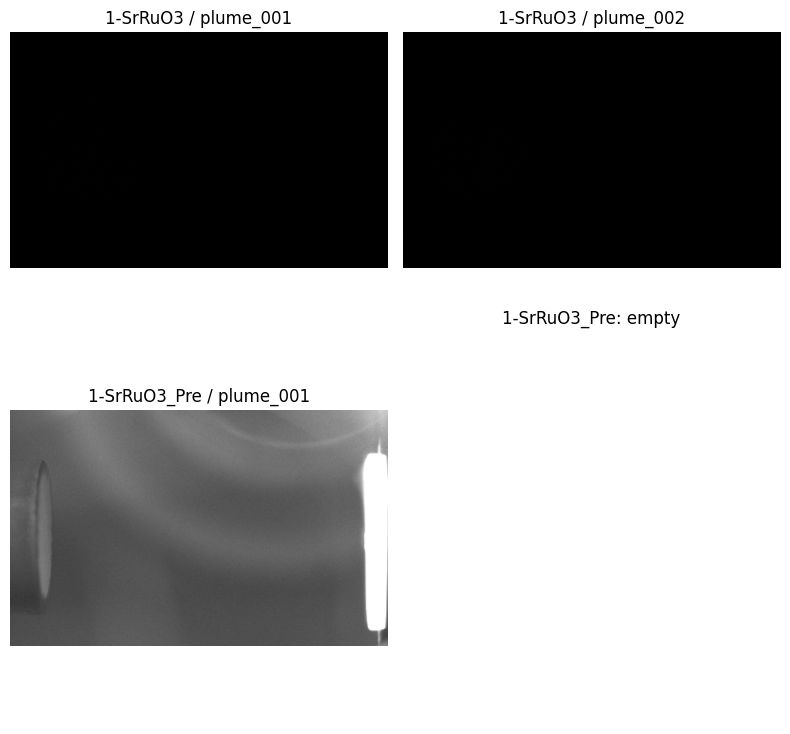

In [6]:
plot_showcase_preview(SHOWCASE_ROOT)

## What this gives you

- A small real-looking folder tree that your plume manager UI can browse.
- A matching metadata JSON file you can load into the metadata editor.
- A tiny repacked `.h5` archive so you can verify the export/import round trip.

A good default for demos is `2` targets, `2` plume folders per target, and `4-6` frames per plume. That is usually enough to show the hierarchy and preview behavior without making the notebook or repo heavy.